<a href="https://colab.research.google.com/github/peculab/DFTDescriptorPipeline/blob/main/examples/indigo_diaryl/indigo_diaryl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /usr/local/lib/python3.11/dist-packages/descriptors

In [2]:
# ✅ Reset environment
%cd /content
import shutil, os, sys, importlib

# 🔁 Uninstall pip-installed descriptors
!pip uninstall -y descriptors

# 🔥 Clear cached modules
for k in list(sys.modules.keys()):
    if k.startswith("descriptors"):
        del sys.modules[k]

# 🧹 Remove previous repo
if os.path.exists("DFTDescriptorPipeline"):
    shutil.rmtree("DFTDescriptorPipeline")

/content


In [3]:
# ✅ Install required packages
!pip install morfeus-ml scikit-learn joblib matplotlib openpyxl

# ✅ Clone the latest repo
!git clone https://github.com/peculab/DFTDescriptorPipeline.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00
Cloning into 'DFTDescriptorPipeline'...
remote: Enumerating objects: 1063, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 1063 (delta 48), reused 26 (delta 26), pack-reused 987 (from 3)
Receiving objects: 100% (1063/1063), 40.13 MiB | 28.79 MiB/s, done.
Resolving deltas: 100% (601/601), done.


In [4]:
# ✅ Set module path
from morfeus import read_xyz, Sterimol
from morfeus.utils import get_radii

import shutil, os, sys, importlib
sys.path.insert(0, "/content/DFTDescriptorPipeline/descriptors")
import extractor_regr
import glob, os
importlib.reload(extractor_regr)

<module 'extractor_regr' from '/content/DFTDescriptorPipeline/descriptors/extractor_regr.py'>

Streaming output truncated to the last 5000 lines.
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_Ster_L'] | R²=0.753 | Q²=0.437
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_Ster_B1'] | R²=0.722 | Q²=0.475
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_Ster_B5'] | R²=0.718 | Q²=0.386
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_I_C=O'] | R²=0.855 | Q²=0.574
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_dp'] | R²=0.861 | Q²=0.603
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_polar'] | R²=0.852 | Q²=0.580
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_LUMO'] | R²=0.907 | Q²=0.723
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_HOMO'] | R²=0.806 | Q²=0.530
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_L_C1_C2'] | R²=0.804 | Q²=0.495
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_c'] | R²=0.798 | Q²=0.460
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_e'] | R²=0.788 | Q²=0.512
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_a'] | R²=0.798 | Q²=0.460
✅ ['Ar1_Ar_Ster_B1', 'Ar2_Ar_v_C=O', 'Ar2_Ar_b'] | R²=0.803

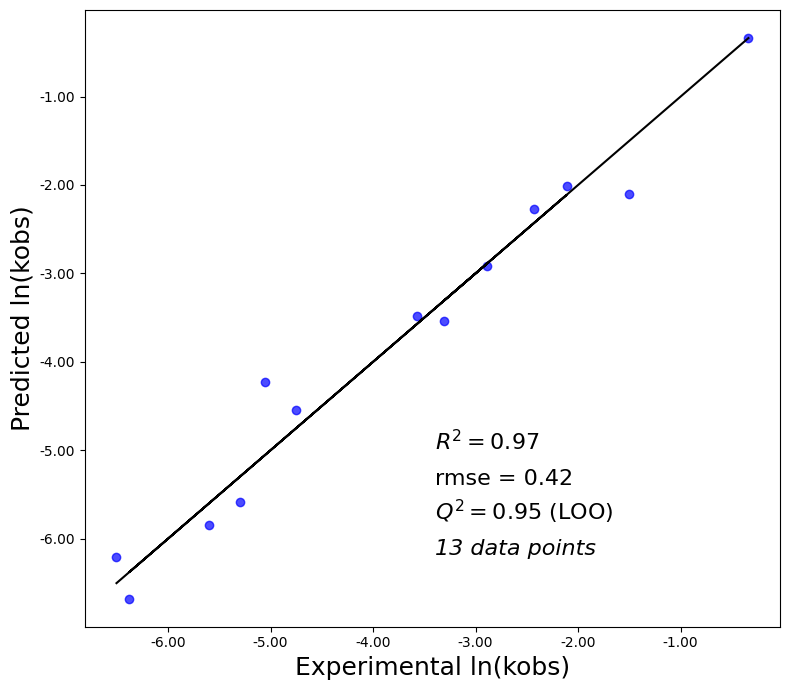


✅ Analysis complete!


In [5]:
data_dir = "/content/DFTDescriptorPipeline/examples/indigo_diaryl"
xlsx_path = glob.glob(os.path.join(data_dir, "*.xlsx"))[0]
log_folder = os.path.join(data_dir, "logfiles")

# One-click execution
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=3,
    target='ln(kobs)'
)

In [6]:
import pandas as pd

target = "ln(kobs)"
features = [c for c in df.columns if c.startswith("Ar") and "_" in c and not c.endswith(("_Ar", "_Ar_key", "_log_path", "_log_exists"))]

mask_missing = df[features + [target]].isna().any(axis=1)
dropped = df[mask_missing].copy()
dropped["missing_features"] = (
    df[features + [target]]
    .isna()
    .apply(lambda row: [c for c, v in row.items() if v], axis=1)
)

print(f"org dataset: {len(df)}")
print(f"missing dataset: {mask_missing.sum()}")
display(dropped[["Ar1", "Ar2", "missing_features"]])

org dataset: 13
missing dataset: 0


,Ar1,Ar2,missing_features
0,NaN,NaN,[]
1,NaN,NaN,[]
2,NaN,NaN,[]
3,NaN,NaN,[]
4,NaN,NaN,[]
5,NaN,NaN,[]
6,NaN,NaN,[]
7,NaN,NaN,[]
8,NaN,NaN,[]
9,NaN,NaN,[]


In [7]:
need = [c for c in df.columns if c.endswith(("_Ar_f","_Ar_g"))]
missing = df[need].isna().any(axis=1)
print("missing f/g：", int(missing.sum()))
display(df.loc[missing, ["Ar1","Ar2"] + need].head(10))

missing f/g： 0


,Ar1,Ar2,Ar1_Ar_f,Ar1_Ar_g,Ar2_Ar_f,Ar2_Ar_g


Streaming output truncated to the last 5000 lines.
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_v_C=O', 'Ar2_HOMO', 'Ar2_Ar_e'] | R²=0.896 | Q²=0.749
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_v_C=O', 'Ar2_Ar_c', 'Ar2_Ar_e'] | R²=0.825 | Q²=0.682
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_NBO_C2', 'Ar2_HOMO'] | R²=0.900 | Q²=0.692
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_NBO_C2', 'Ar2_Ar_LUMO'] | R²=0.892 | Q²=0.664
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_NBO_=O', 'Ar2_Ar_g'] | R²=0.798 | Q²=0.580
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_NBO_-O', 'Ar2_Ster_B1'] | R²=0.868 | Q²=0.589
❌ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_dp', 'Ar2_Ar_NBO_C2'] | skipped
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_LUMO', 'Ar2_Ar_NBO_-O'] | R²=0.890 | Q²=0.630
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_HOMO'] | R²=0.907 | Q²=0.609
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_Ar_v_C=O', 'Ar2_Ar_LUMO'] | R²=0.870 | Q²=0.487
✅ ['Ar1_Ar_NBO_C2', 'Ar1_Ar_I_C=O', 'Ar2_Ar_v_C=O', 'Ar2_L_C1_C2'] | R²=0.861 | Q²=0.397
✅ ['Ar1_Ar_NBO_

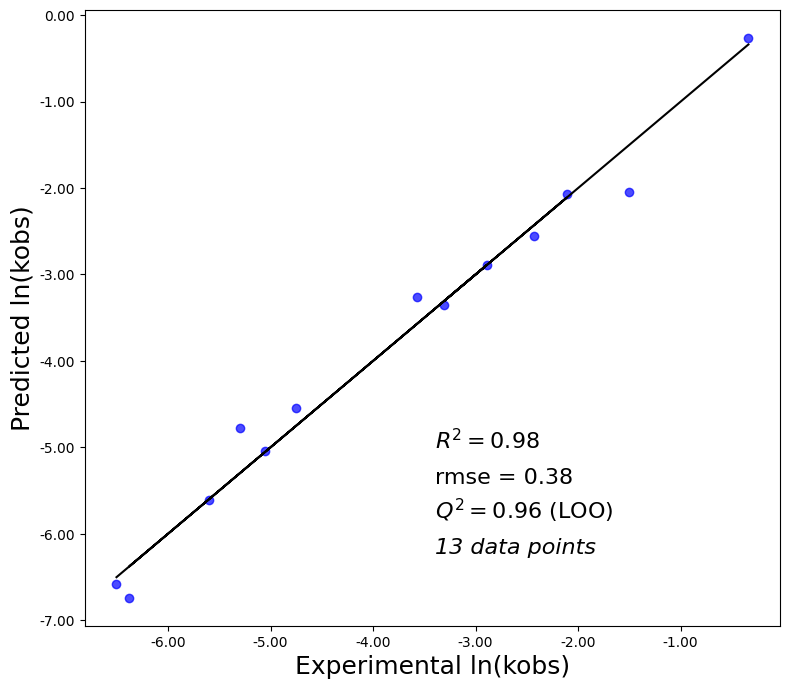


✅ Analysis complete!


In [8]:
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=4,
    target='ln(kobs)'
)

Streaming output truncated to the last 5000 lines.
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_I_C=O'] | R²=0.948 | Q²=-256.191
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_L_C1_C2'] | R²=0.878 | Q²=-73.305
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_Ar_a'] | R²=0.878 | Q²=-710.669
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_I_C=O', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_L', 'Ar2_Ar_dp'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_L', 'Ar2_Ar_Ster_B5'] | skipped
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_B1', 'Ar2_Ar_v_C=O'] | R²=0.909 | Q²=-116.975
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_B1', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_polar', 'Ar2_Ar_d'] | skipped
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_HOMO', 'Ar2_Ar_v_C=O'] | R²=0.871 | Q²=-70.028
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ar_dp', 'Ar2_Ar_St

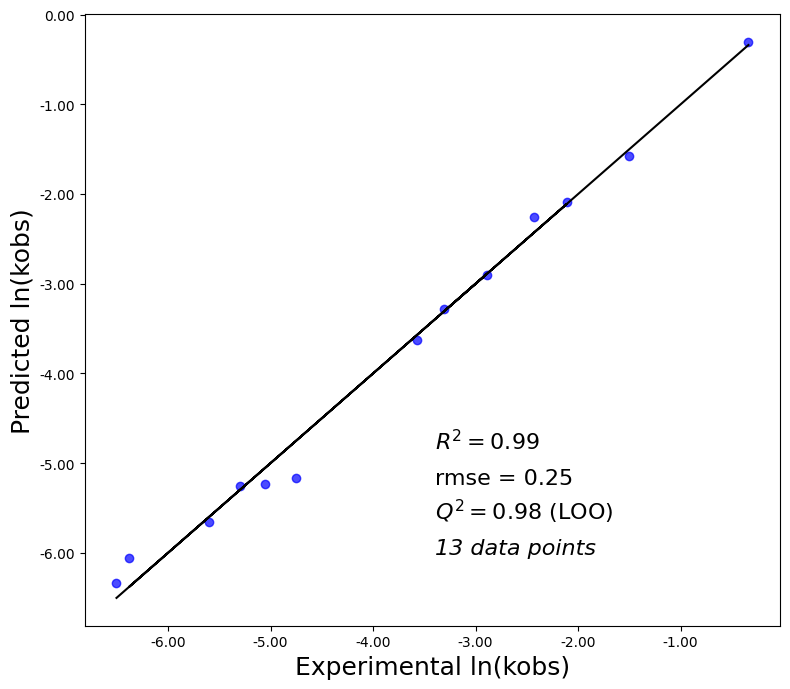


✅ Analysis complete!


In [9]:
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,
    max_features=5,
    target='ln(kobs)'
)